In [1]:
# Basic Librariies
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns 
import pydot

#Evaluation libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep Learning Libraries

import tensorflow as tf 
from tensorflow.keras import layers
import keras 
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import Activation,Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers  import KerasClassifier


In [2]:
#! pip install pydot
#pip install 
#!pip install scikeras

In [3]:
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

In [4]:
X_train_digit[1]


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [5]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

<function matplotlib.pyplot.show(close=None, block=None)>

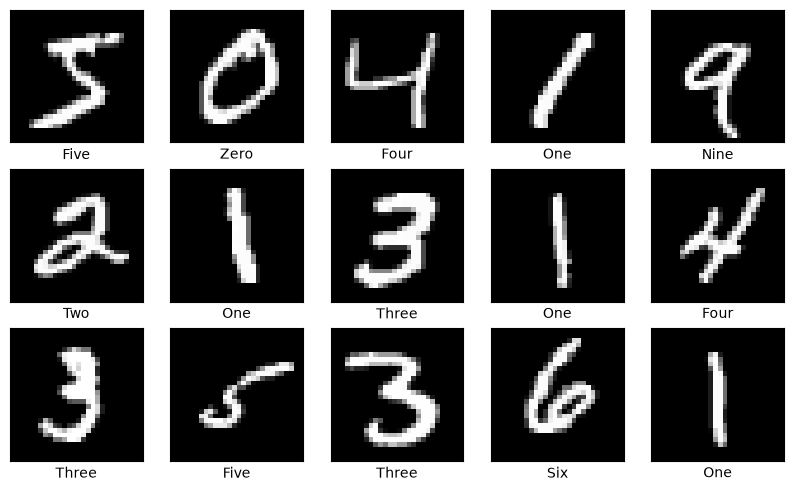

In [6]:
# Name of numbers in the dataset in order
col_names = ["Zero", "One", "Two", "Three", "Four", "Five", "Six", "Sevan", "Eight", "Nine"]

# visualizing the digits

plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])

plt.show

In [7]:
X_train_digit.shape

(60000, 28, 28)

In [8]:
X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)

In [9]:
X_train_digit.shape

(60000, 784)

In [10]:
y_test_digit.shape

(10000,)

In [11]:
#Encoding Digit MNIST labels

y_train_digit = to_categorical(y_train_digit, num_classes = 10)
y_test_digit = to_categorical(y_test_digit, num_classes = 10)

In [12]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [13]:
# Creating Base Neural Network

model = keras.Sequential([layers.Dense(256, activation='relu', input_shape=(784,)),
                          layers.Dense(64, activation='relu'),
                          layers.Dense(64, activation='relu'),
                          layers.Dense(10, activation='sigmoid')])

C:\Anaconda3\envs\aiml\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compling the model 

model.compile(loss="categorical_crossentropy",
              optimizer = "adam",
              metrics = ['accuracy'])

In [16]:
history = model.fit(X_train_digit, y_train_digit, batch_size=100, epochs=10, validation_data=(X_test_digit,y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5997 - loss: 1.4479 - val_accuracy: 0.6595 - val_loss: 0.3952
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7443 - loss: 0.2594 - val_accuracy: 0.7929 - val_loss: 0.2778
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7754 - loss: 0.1705 - val_accuracy: 0.7758 - val_loss: 0.1856
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7720 - loss: 0.1193 - val_accuracy: 0.7562 - val_loss: 0.1813
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7447 - loss: 0.1155 - val_accuracy: 0.7317 - val_loss: 0.1784
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7499 - loss: 0.1001 - val_accuracy: 0.7838 - val_loss: 0.1637
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7615 - loss: 0.0909 - val_accuracy: 0.7513 - val_loss: 0.1705
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7775 - loss: 0.0850 - val_accuracy: 0.

In [18]:
# Predicting the model 

y_predict = model.predict(X_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [20]:
y_predict[0]

array([9.9896282e-01, 9.1468386e-02, 9.9998027e-01, 9.9998635e-01,
       1.0895380e-01, 3.2170271e-03, 2.3490866e-08, 1.0000000e+00,
       9.9939311e-01, 9.9996215e-01], dtype=float32)

In [25]:
# Here we get the index of maximum value in the encoded vector 
y_predicts =np.argmax(y_predict, axis=1)# Predicted Data
y_predicts

array([7, 2, 1, ..., 4, 2, 6], shape=(10000,))

In [26]:
y_test_digit_eval = np.argmax(y_test_digit, axis=1) # Actual Data
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

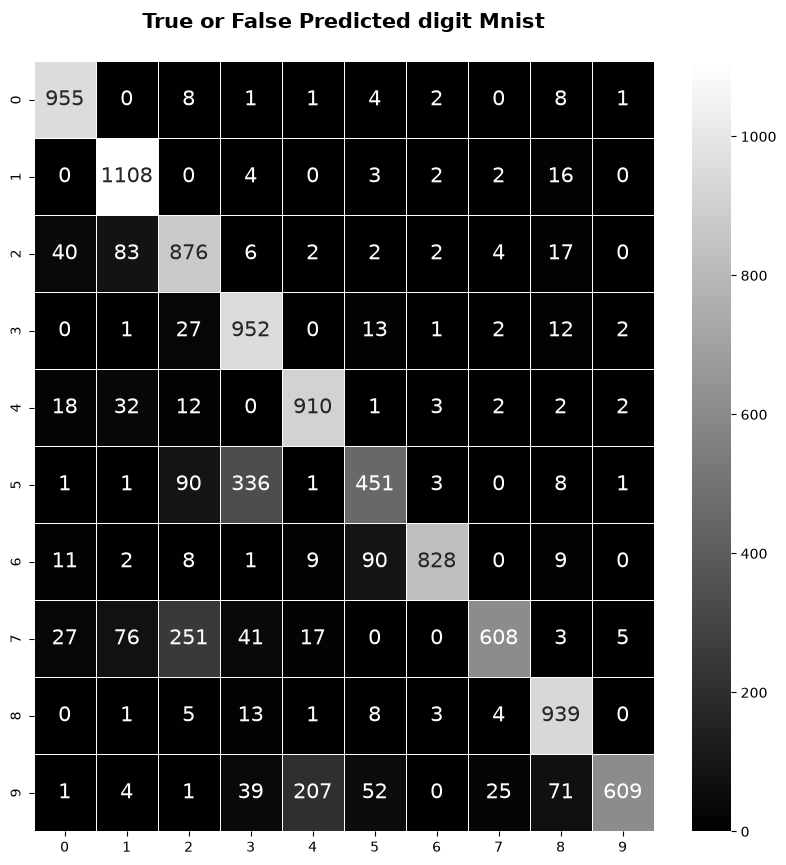

In [33]:
# Confusion Matrix for Digit Mnist

con_mat = confusion_matrix(y_test_digit_eval, y_predicts)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True, annot_kws={'size' : 15}, linewidths=0.5, fmt="d", cmap="gray")
plt.title("True or False Predicted digit Mnist\n", fontweight='bold', fontsize=15)
plt.show()

In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test_digit_eval, y_predicts))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       980
           1       0.85      0.98      0.91      1135
           2       0.69      0.85      0.76      1032
           3       0.68      0.94      0.79      1010
           4       0.79      0.93      0.85       982
           5       0.72      0.51      0.59       892
           6       0.98      0.86      0.92       958
           7       0.94      0.59      0.73      1028
           8       0.87      0.96      0.91       974
           9       0.98      0.60      0.75      1009

    accuracy                           0.82     10000
   macro avg       0.84      0.82      0.82     10000
weighted avg       0.84      0.82      0.82     10000



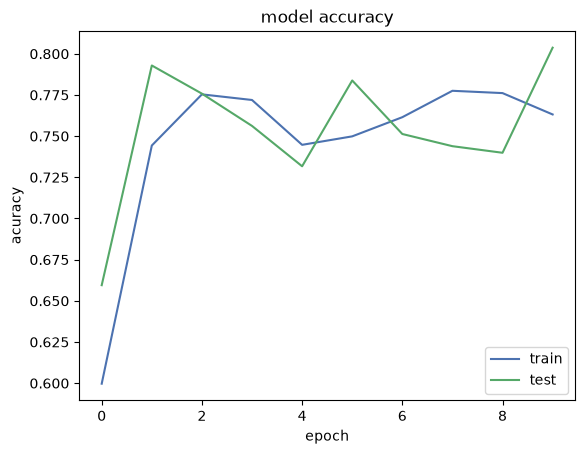

In [37]:
# Summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('acuracy')
plt.legend(['train', 'test'], loc='best')
plt.show()

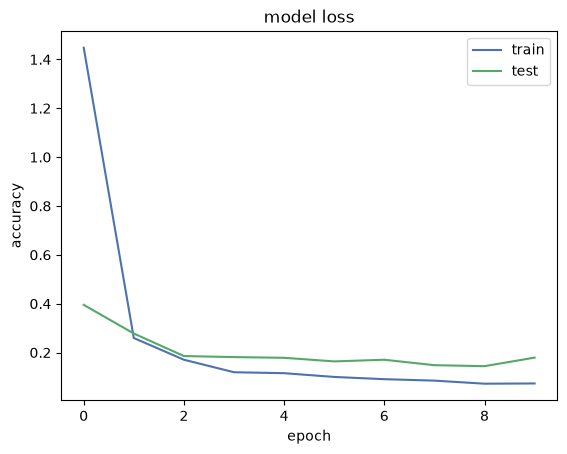

In [40]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [44]:
y_predict_single = model.predict(X_test_digit[[2]])
y_predicts_single = np.argmax(y_predict_single, axis=1)
y_test_digit_eval = np.argmax(y_test_digit, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


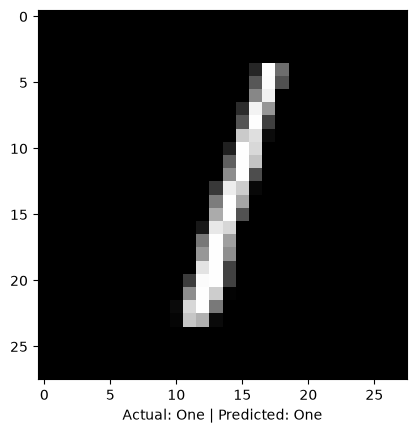

In [46]:
# Names of numbers in the dataset in order 

col_names = ['Zero', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Sevan', 'Eight', 'Nine']

plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')
plt.xlabel("Actual: {} | Predicted: {}". format(col_names[np.argmax(y_test_digit[2])], col_names[y_predicts_single[0]]))
plt.show()